In [21]:
import sys
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from hyperopt import fmin, tpe, hp, Trials
from scipy.integrate import solve_ivp
import warnings
warnings.filterwarnings("ignore")

In [22]:
# --------------- Set up project root path  --------------- #
project_folder_name = "MFC2024" # Set this to the name of your project root folderS
project_root = next((p for p in [Path.cwd(), *Path.cwd().parents] if p.name == project_folder_name), None)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
# --------------- Import custom modules  --------------- #
from model.dualscale import PEMFC
from model.coefficients import *
from modules.signals import generate_step_load
from config.initialize import *
from config.settings import *

In [23]:
# --- Global parameters ---
tstart     = 0.0      # start of each period                    [s]
tend       = 6.0    # end of each period                      [s]
i_low      = 0.002e4      # baseline current density                [A/m^2]
i_high     = 1.2e4    # plateau current density                 [A/m^2]
tau_switch = 1.5    # time (within a period) the ramp BEGINS  [s]
t_switch   = 0.3    # effective ramp duration                 [s]

step_load = generate_step_load(tstart, tend, i_low, i_high, tau_switch, t_switch)

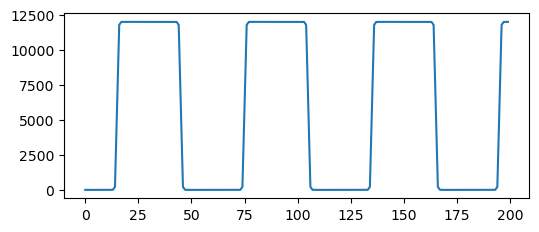

In [24]:
plt.figure(figsize=(6, 2.4))
plt.plot([step_load(i) for i in np.arange(0, 20, 0.1)])

In [25]:
operating_inputs = {'current_density': lambda x: 0.1e4, 'Tfc': 353.15, 
                                    'Pa_des': 1.8e5, 'Pc_des': 1.8e5,
                                    'Phi_a_des': 0.0, 'Phi_c_des': 0.85,
                                    'Sa': 1.2, 'Sc': 2.,
                                    'Imin_aux': 10}

accessible_physical_parameters = {'Aact': 31e-4, 'Hmem': 1.2e-5, 'Hgc': 8e-4, 'Wgc': 4e-4, 'Lgc': 1.287} #m

current_parameters = {'t_step': (0, 3600, 100, 1.5), 'i_step': (0.5e4, 1.5e4),
                                        'delta_pola': (30, 30, 0.1e4, 60), 'i_max_pola': 1.65e4, # 50A
                                        'i_EIS': 1.0e4, 'ratio_EIS': 0.05, 't_EIS': 15, 'f_EIS': (-3, 5, 90, 50)}
 
undetermined_physical_parameters = {'epsilon_gdl': 0.55, "epsilon_cl": 0.35,
                                                                'epsilon_mc': 0.399,'epsilon_c': 0.189, 
                                                                'e': 3, 'kappa_co': 37.2, 'Re': 2.2e-6, 'tau': 1.01, 
                                                                'i0_c_ref': 2.16, 'kappa_c': 1.9, 'C_scl': 1e8, 
                                                                'a_slim': 0.4, 'b_slim': 0.5, 'a_switch': 0.5,
                                                                "Hcl": 1.e-5, "Hgdl": 2.8e-4, "OCV": 0.92}

computing_parameters = {'max_step': 0.1, 'n_gdl': 10,'n_mem':10,'n_group_pt':10,
                                            't_purge': (2.4, 15), 'type_fuel_cell': "LEV-200", 'type_control': "Phi_des", 'type_purge': "constant_purge"}

parameters = {**current_parameters, **accessible_physical_parameters,
                          **undetermined_physical_parameters, **computing_parameters}

In [26]:
Kp = 1e-6  # m².s-1.Pa-1. It is the proportional constant of the PD controller at the throttle
Kd = 1e-7  # m².s-1.Pa-1. It is the derivative constant of the PD controller at the throttle
C_D = 0.4  # . It is the throttle discharge coefficient.
Ksm_in = 2.0e-8  # kg.s-1.Pa-1. It is the supply manifold inlet orifice constant.
Ksm_out = 1.0e-8  # kg.s-1.Pa-1. It is the supply manifold outlet orifice constant.
Kem_in = 2.0e-8  # kg.s-1.Pa-1. It is the exhaust manifold inlet orifice constant.
Kem_out = 1.0e-8  # kg.s-1.Pa-1. It is the exhaust manifold outlet orifice constant.

In [27]:
operating_inputs["current_density"] = step_load
operating_inputs["Phi_c_des"] = 0.85
operating_inputs["Sa"] = 1.2
operating_inputs["Sc"] = 2
operating_inputs["Pa_des"] = 1.8e5
operating_inputs["Pc_des"] = 1.8e5
operating_inputs["Tfc"] = 353.15
model = PEMFC(param=parameters, operating_inputs=operating_inputs, variable_names=solver_variable_names, flux_names=solver_flux_names)
solution_init = init_x(operating_inputs, parameters)
sol = solve_ivp(fun = model.dxdt, y0=solution_init, t_span=(0, 100), method='BDF', max_step = 1e-1)

ValueError: array must not contain infs or NaNs

In [ ]:
model._recovery(sol)

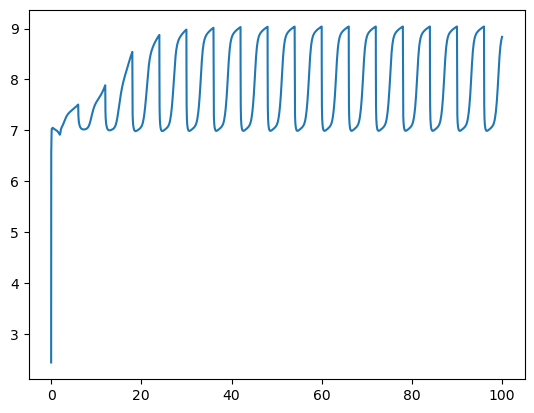

In [ ]:
plt.plot(model.variables["t"],model.variables["C_v_ccl"])

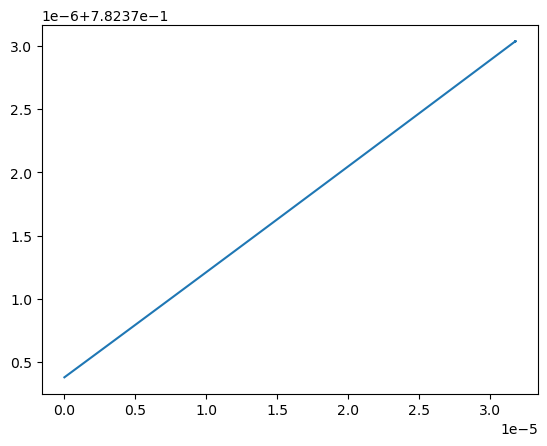

In [ ]:
plt.plot(model.variables["t"],model.echem_traj["Ucell"])

In [ ]:
sol = solve_ivp(fun = model.dxdt, y0=solution_init, t_span=(0, 5000*6), method='BDF')

In [ ]:
model._recovery(sol)

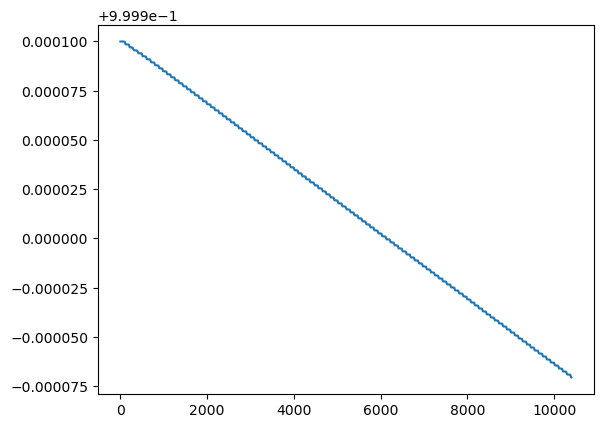

In [ ]:
plt.plot(model.echem_traj["S_N"])